# Лекция 5: Архитектура на трансформатора

## Преговор от Лекция 4

В Лекция 4 разгледахме **механизъма на вниманието (attention)**:

- **Изчезващи градиенти** — дълбоките вериги и RNN губят градиентен сигнал с нарастване на дължината
- **Самовнимание (self-attention)** — всеки токен може директно да "погледне" всеки друг, с O(1) дължина на пътя
- **Q, K, V** — три отделни проекции за запитване, ключ и стойност
- **Формулата:** $\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$
- **Внимание с множество насоки (multi-head attention)** — паралелни "въпроси" за различни аспекти
- **Причинно маскиране** — при езиково моделиране токен $t$ вижда само позиции $1..t$

Останаха важни въпроси: как моделът знае **реда** на токените? Какво е **мрежата с пряко предаване (FFN)**? Защо са нужни **остатъчни връзки** и **нормализация на слоя**? Точно това ще покрием днес.

## Какво ще разгледаме днес

| Блок | Тема | Тип |
|------|------|-----|
| 1 | Пълният трансформаторен блок | Обяснение + Демо |
| 2 | Три архитектури на трансформатора | Обяснение |
| 3 | Позиционно кодиране | Обяснение + Демо |
| 4 | Активационни функции | Обяснение + Демо |
| 5 | FFN, остатъчни връзки, нормализация на слоя | Обяснение + Демо |
| 6 | nanoGPT: код и обучение | Демо |
| 7 | nanoGPT: изследване + Обобщение | Демо + Дискусия |

In [57]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import json

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
print("Библиотеките са заредени.")

Device: cpu
Библиотеките са заредени.


---

## Блок 1: Пълният трансформаторен блок [Обяснение + Демо]

**Цел:** Да видим цялата картина — от какво е изграден един трансформаторен блок, да го дефинираме в PyTorch и да го разпознаем в GPT-2.

### Компоненти отгоре надолу

Пълният блок (pre-norm вариант, използван в GPT-2 и повечето модерни модели):

```
x → LayerNorm → Multi-Head Attention → + x (остатъчна връзка)
  → LayerNorm → FFN                  → + x (остатъчна връзка)
```

- **Внимание с множество насоки** — вече познато от Лекция 4: смесва информация *между* позиции
- **FFN (мрежа с пряко предаване)** — трансформира информацията *на* всяка позиция поотделно
- **Остатъчни връзки** — "прескачат" подслоя, градиентите текат директно
- **Нормализация на слоя (Layer Norm)** — нормализира активациите, стабилизира обучението
- **Позиционно кодиране** — добавя се *преди* блоковете, казва на модела *къде* е всеки токен

![transformer_block](images/transformer_block.png)

### Демо: TransformerBlock в PyTorch

Дефинираме минимален трансформаторен блок в ~20 реда.

In [2]:
class SimpleMultiHeadAttention(nn.Module):
    """Simplified multi-head self-attention with causal mask."""
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.c_attn = nn.Linear(d_model, 3 * d_model)
        self.c_proj = nn.Linear(d_model, d_model)

    def forward(self, x):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(C, dim=2)
        q = q.view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.c_proj(y)

print("SimpleMultiHeadAttention — дефиниран.")

SimpleMultiHeadAttention — дефиниран.


In [3]:
class TransformerBlock(nn.Module):
    """One transformer block: LN -> MHA -> residual -> LN -> FFN -> residual."""
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.ln_1 = nn.LayerNorm(d_model)
        self.attn = SimpleMultiHeadAttention(d_model, n_heads)
        self.ln_2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Linear(4 * d_model, d_model),
        )

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.ffn(self.ln_2(x))
        return x

print("TransformerBlock — дефиниран.")

TransformerBlock — дефиниран.


Пускаме тензор през блока и проверяваме формите.

In [58]:
d_model, n_heads = 64, 4
block = TransformerBlock(d_model, n_heads)

x = torch.randn(1, 16, d_model)  # batch=1, seq_len=16, d_model=64
y = block(x)

print(f"Вход:  {x.shape}")
print(f"Изход: {y.shape}")
print(f"Формата е запазена — блокът трансформира, без да променя размерите.")

Вход:  torch.Size([1, 16, 64])
Изход: torch.Size([1, 16, 64])
Формата е запазена — блокът трансформира, без да променя размерите.


In [59]:
block

TransformerBlock(
  (ln_1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (attn): SimpleMultiHeadAttention(
    (c_attn): Linear(in_features=64, out_features=192, bias=True)
    (c_proj): Linear(in_features=64, out_features=64, bias=True)
  )
  (ln_2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (ffn): Sequential(
    (0): Linear(in_features=64, out_features=256, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=256, out_features=64, bias=True)
  )
)

### Подреждане на блокове

Пълният модел = токен вграждания + позиционно кодиране + $N$ × TransformerBlock + LayerNorm + изходна глава.

| Модел | Блокове ($N$) | $d_{model}$ | Глави |
|-------|--------------|-------------|-------|
| GPT-2 small | 12 | 768 | 12 |
| GPT-2 XL | 48 | 1600 | 25 |
| LLaMA 7B | 32 | 4096 | 32 |
| LLaMA 70B | 80 | 8192 | 64 |

Зареждаме GPT-2 (124M) и отпечатваме архитектурата — студентите разпознават всеки компонент.

In [60]:
from transformers import GPT2Model

gpt2 = GPT2Model.from_pretrained("gpt2")
print(gpt2)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


GPT2Model(
  (wte): Embedding(50257, 768)
  (wpe): Embedding(1024, 768)
  (drop): Dropout(p=0.1, inplace=False)
  (h): ModuleList(
    (0-11): 12 x GPT2Block(
      (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (attn): GPT2Attention(
        (c_attn): Conv1D(nf=2304, nx=768)
        (c_proj): Conv1D(nf=768, nx=768)
        (attn_dropout): Dropout(p=0.1, inplace=False)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
      (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (mlp): GPT2MLP(
        (c_fc): Conv1D(nf=3072, nx=768)
        (c_proj): Conv1D(nf=768, nx=3072)
        (act): NewGELUActivation()
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
)


Броим параметрите по компонент.

In [61]:
def count_params(module):
    return sum(p.numel() for p in module.parameters())

print(f"Общо параметри:       {count_params(gpt2):>12,}")
print(f"Токен вграждания:     {count_params(gpt2.wte):>12,}")
print(f"Позиционни вграждания:{count_params(gpt2.wpe):>12,}")
print(f"Трансформаторни блокове:")
for i, block in enumerate(gpt2.h):
    if i < 2 or i == 11:
        print(f"  Блок {i:2d}:             {count_params(block):>12,}")
    elif i == 2:
        print(f"  ...")
print(f"Финален LayerNorm:    {count_params(gpt2.ln_f):>12,}")

Общо параметри:        124,439,808
Токен вграждания:       38,597,376
Позиционни вграждания:     786,432
Трансформаторни блокове:
  Блок  0:                7,087,872
  Блок  1:                7,087,872
  ...
  Блок 11:                7,087,872
Финален LayerNorm:           1,536


---

## Блок 2: Три архитектури на трансформатора [Обяснение]

**Цел:** Сега, когато знаем какво има *вътре* в един блок, да видим трите основни начина, по които блоковете се подреждат в модел.

### Оригиналният трансформатор (Vaswani et al., 2017)

Статията *"Attention Is All You Need"* предлага архитектура за **машинен превод**: един език влиза, друг излиза.

Два стека:
- **Енкодер** — разбира входната редица (двупосочно внимание)
- **Декодер** — генерира изходната редица (причинно маскиране + кръстосано внимание към енкодера)

![arc](images/arc.png)

### Три варианта

От оригиналната архитектура се раждат три семейства:

**1. Само енкодер (Encoder-only): BERT**
- Двупосочно внимание — всеки токен вижда всеки друг (без причинна маска)
- Задача за обучение: **маскирано езиково моделиране (MLM)** — скриваме 15% от токените и ги предсказваме
- Силни страни: класификация, извличане на именувани обекти, семантично търсене
- Слабост: не генерира текст авторегресивно

**2. Само декодер (Decoder-only): GPT**
- Причинно маскиране — токен $t$ вижда само $1..t$ (както в Лекция 4)
- Задача за обучение: **предвиждане на следващ токен**
- Днес доминиращ подход: GPT-4, Claude, LLaMA, Gemini, Mistral
- Защо? По-прост, мащабира по-добре, instruction tuning го прави универсален

**3. Енкодер-декодер: T5, Whisper**
- Енкодерът кодира входа (двупосочно), декодерът генерира изхода (причинно)
- **Кръстосано внимание:** декодерът "гледа" към енкодера — Q от декодера, K и V от енкодера
- Примери: T5, BART, Whisper (аудио → текст)

![three_arc](images/three_arc.webp)

### Сравнителна таблица

| Архитектура | Маска за внимание | Задача за обучение | Типични модели |
|-------------|-------------------|--------------------|----------------|
| Само енкодер | Двупосочна | MLM | BERT, RoBERTa |
| Само декодер | Причинна | Следващ токен | GPT, LLaMA, Claude |
| Енкодер-декодер | Двупосочна + причинна + кръстосана | Seq2seq | T5, BART, Whisper |

---

## Блок 3: Позиционно кодиране [Обяснение + Демо]

**Цел:** Как моделът знае реда на токените?

### Защо е нужно?

Вниманието е **инвариантно спрямо пермутации** — ако разбъркаме позициите на токените, скаларните произведения остават същите. Без позиционна информация:

- "котката яде рибата" = "рибата яде котката"

Трябва да **инжектираме** информация за позицията.

### 1. Синусоидално кодиране (Vaswani et al.)

Фиксирана функция (без обучаеми параметри):

$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$
$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

Различни честоти за всяко измерение — позициите са уникални вълнови комбинации.

In [7]:
def sinusoidal_encoding(max_len, d_model):
    pe = torch.zeros(max_len, d_model)
    position = torch.arange(0, max_len).unsqueeze(1).float()
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe

pe = sinusoidal_encoding(128, 64)
print(f"Форма: {pe.shape} (позиции × измерения)")

Форма: torch.Size([128, 64]) (позиции × измерения)


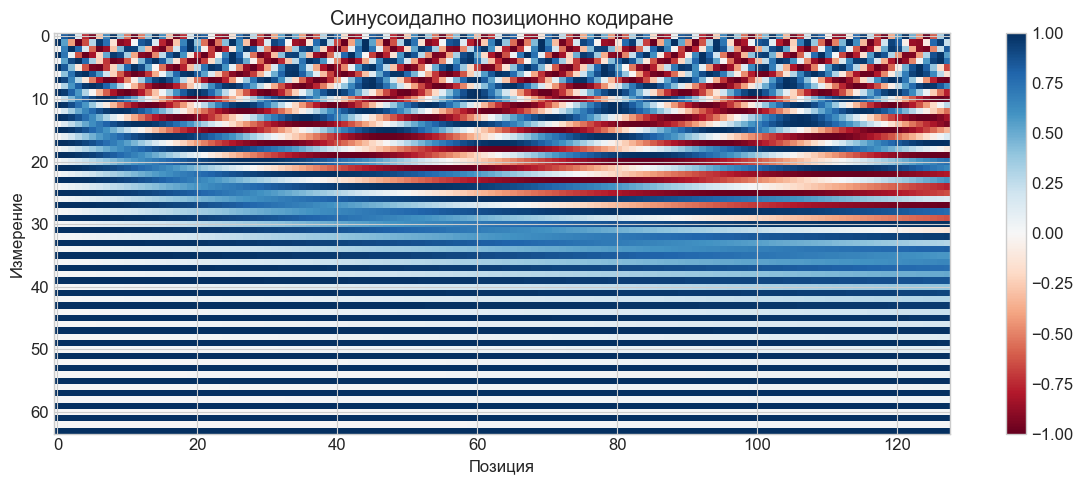

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(pe.numpy().T, aspect='auto', cmap='RdBu', interpolation='nearest')
ax.set_xlabel('Позиция')
ax.set_ylabel('Измерение')
ax.set_title('Синусоидално позиционно кодиране')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

Ниските измерения имат бързи вълни (високи честоти), високите — бавни. Всяка позиция получава уникален "пръстов отпечатък".

### 2. Обучаеми позиционни вграждания (GPT-2)

GPT-2 използва `nn.Embedding(max_seq_len, d_model)` — позицията е просто поредния индекс, а вграждането се учи при обучение.

Да заредим позиционните вграждания от GPT-2 и да ги разгледаме.

In [9]:
pos_emb = gpt2.wpe.weight.detach()
print(f"Форма: {pos_emb.shape}  (макс. позиции × d_model)")
print(f"GPT-2 поддържа до {pos_emb.shape[0]} позиции.")

Форма: torch.Size([1024, 768])  (макс. позиции × d_model)
GPT-2 поддържа до 1024 позиции.


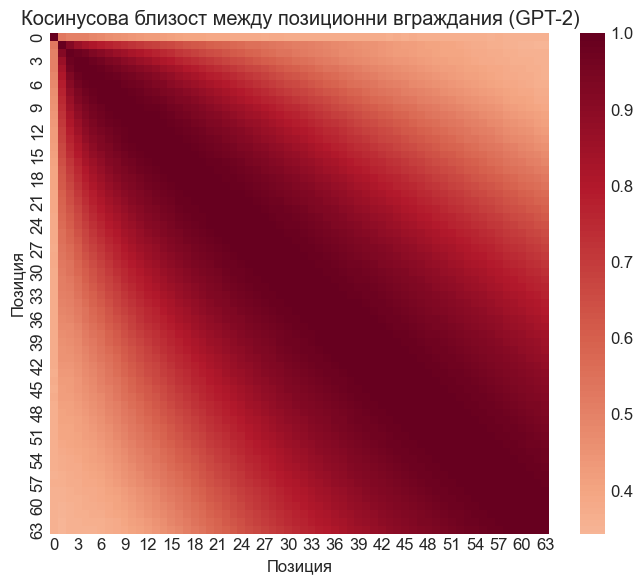

In [10]:
# Косинусова близост между позиции
pos_subset = pos_emb[:64]  # първите 64 позиции
cos_sim = F.cosine_similarity(
    pos_subset.unsqueeze(0), pos_subset.unsqueeze(1), dim=-1
)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cos_sim.numpy(), cmap='RdBu_r', center=0, ax=ax)
ax.set_xlabel('Позиция')
ax.set_ylabel('Позиция')
ax.set_title('Косинусова близост между позиционни вграждания (GPT-2)')
plt.tight_layout()
plt.show()

Близките позиции имат по-висока косинусова близост — моделът е научил, че съседните токени са по-свързани. Ограничение: фиксиран максимален брой позиции (1024 за GPT-2) — моделът не обобщава отвъд тренировъчната дължина.

---

*Почивка*

---

## Блок 4: Активационни функции [Обяснение + Демо]

**Цел:** От sigmoid/tanh до съвременни нелинейности — какво се случва вътре в FFN от Блок 1.

### От sigmoid и tanh до ReLU

Кратко припомняне от Лекция 2:
- **sigmoid** и **tanh** — наситяват се при големи $|x|$, градиентите изчезват
- **ReLU** $\max(0, x)$: просто, бързо, не се наситява за $x > 0$
- Проблем с ReLU: "умиращи неврони" — ако $x < 0$, градиентът е 0 завинаги

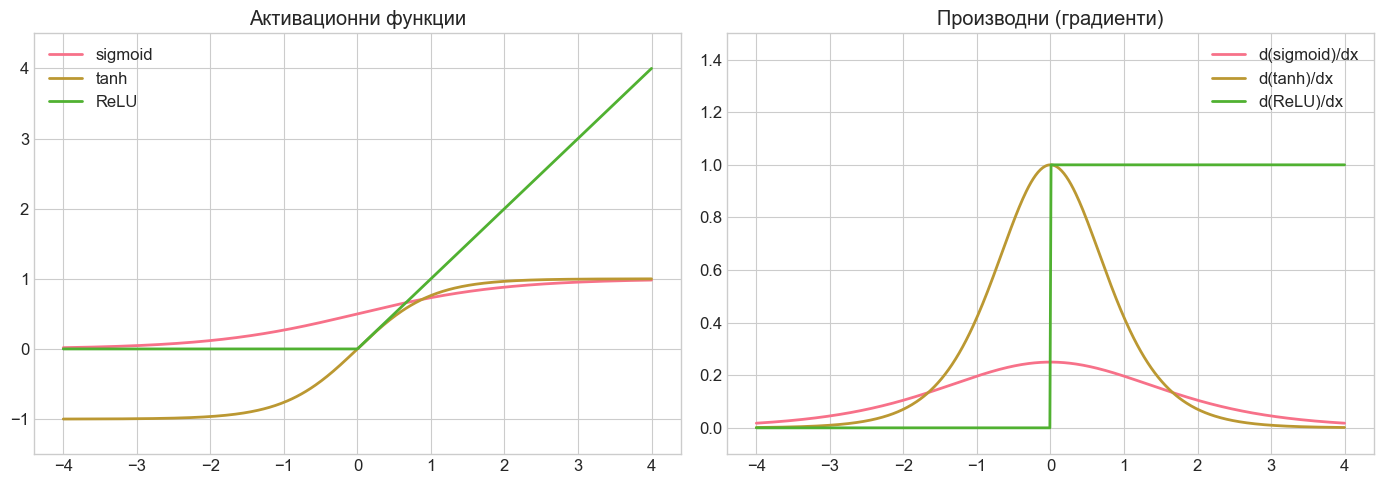

In [11]:
x = torch.linspace(-4, 4, 500)

sigmoid = torch.sigmoid(x)
tanh = torch.tanh(x)
relu = F.relu(x)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Функции
axes[0].plot(x, sigmoid, label='sigmoid', linewidth=2)
axes[0].plot(x, tanh, label='tanh', linewidth=2)
axes[0].plot(x, relu, label='ReLU', linewidth=2)
axes[0].set_title('Активационни функции')
axes[0].legend()
axes[0].set_ylim(-1.5, 4.5)

# Производни
x_grad = x.clone().requires_grad_(True)

for fn, name in [(torch.sigmoid, 'sigmoid'), (torch.tanh, 'tanh'), (F.relu, 'ReLU')]:
    x_g = x.clone().requires_grad_(True)
    y = fn(x_g)
    grad = torch.autograd.grad(y.sum(), x_g)[0]
    axes[1].plot(x.detach(), grad.detach(), label=f'd({name})/dx', linewidth=2)

axes[1].set_title('Производни (градиенти)')
axes[1].legend()
axes[1].set_ylim(-0.1, 1.5)

plt.tight_layout()
plt.show()

sigmoid и tanh имат градиент ≈ 0 при големи $|x|$. ReLU запазва градиент = 1 за $x > 0$, но е точно 0 за $x < 0$.

### Нелинейности в трансформатори

**GELU** (Gaussian Error Linear Unit): $x \cdot \Phi(x)$, където $\Phi$ е CDF на нормалното разпределение.
- "Мек" ReLU — не е точно 0 за отрицателни стойности, плавен преход
- Използва се в GPT-2, BERT, повечето модерни модели

**SwiGLU**: GELU вариант с гейтинг механизъм — FFN става Linear → SwiGLU → Linear.
- Използва се в LLaMA, Mistral, Gemma

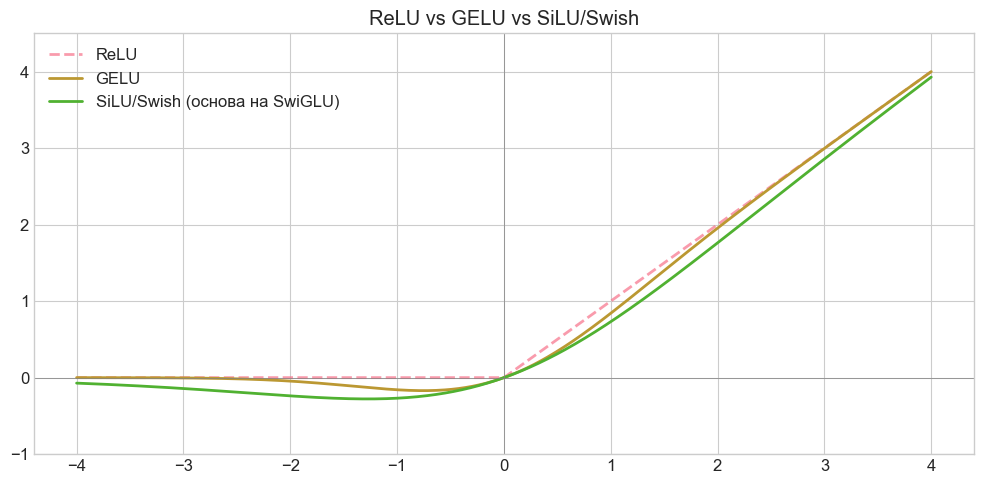

In [12]:
gelu = F.gelu(x)

# SwiGLU approximation: x * sigmoid(beta * x), beta=1
swiglu_approx = x * torch.sigmoid(x)  # SiLU/Swish — основата на SwiGLU

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, relu, label='ReLU', linewidth=2, linestyle='--', alpha=0.7)
ax.plot(x, gelu, label='GELU', linewidth=2)
ax.plot(x, swiglu_approx, label='SiLU/Swish (основа на SwiGLU)', linewidth=2)
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.axvline(x=0, color='gray', linewidth=0.5)
ax.set_title('ReLU vs GELU vs SiLU/Swish')
ax.legend()
ax.set_ylim(-1, 4.5)
plt.tight_layout()
plt.show()

GELU и SiLU/Swish са плавни — не прекъсват рязко при $x = 0$ като ReLU. За трансформатори: по-гладка функция → по-стабилни градиенти в дълбоки мрежи.

### Демо: ефект върху обучението

Обучаваме прост модел с различни активационни функции и сравняваме кривите на загубата.

In [13]:
# Подготовка: текстови данни от корпус на Вазов
with open("../../data/ivan_vazov.txt", "r") as f:
    raw_text = f.read()

# Прост символен речник за демото
chars = sorted(set(raw_text[:5000]))
char_to_idx = {c: i for i, c in enumerate(chars)}
vocab_size = len(chars)
text_ids = torch.tensor([char_to_idx[c] for c in raw_text[:5000]], dtype=torch.long)
print(f"Речник: {vocab_size} символа, текст: {len(text_ids)} токена")

Речник: 64 символа, текст: 5000 токена


In [14]:
class MiniLM(nn.Module):
    """Tiny language model with configurable activation."""
    def __init__(self, vocab_size, d_model, activation_fn):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, d_model)
        self.fc1 = nn.Linear(d_model, 4 * d_model)
        self.act = activation_fn
        self.fc2 = nn.Linear(4 * d_model, vocab_size)

    def forward(self, x):
        h = self.emb(x)
        h = self.fc2(self.act(self.fc1(h)))
        return h

def train_mini(activation_fn, name, steps=500):
    torch.manual_seed(42)
    model = MiniLM(vocab_size, 64, activation_fn)
    optimizer = torch.optim.Adam(model.parameters(), lr=3e-3)
    losses = []
    for step in range(steps):
        idx = torch.randint(0, len(text_ids) - 17, (32,))
        x = torch.stack([text_ids[i:i+16] for i in idx])
        y = torch.stack([text_ids[i+1:i+17] for i in idx])
        logits = model(x)
        loss = F.cross_entropy(logits.view(-1, vocab_size), y.view(-1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses

print("Функции за обучение — дефинирани.")

Функции за обучение — дефинирани.


In [15]:
results = {}
activations = {
    'sigmoid': nn.Sigmoid(),
    'tanh': nn.Tanh(),
    'ReLU': nn.ReLU(),
    'GELU': nn.GELU(),
}

for name, act_fn in activations.items():
    results[name] = train_mini(act_fn, name)
    print(f"{name:>8s}: крайна загуба = {results[name][-1]:.3f}")

 sigmoid: крайна загуба = 2.441
    tanh: крайна загуба = 2.463
    ReLU: крайна загуба = 2.429
    GELU: крайна загуба = 2.433


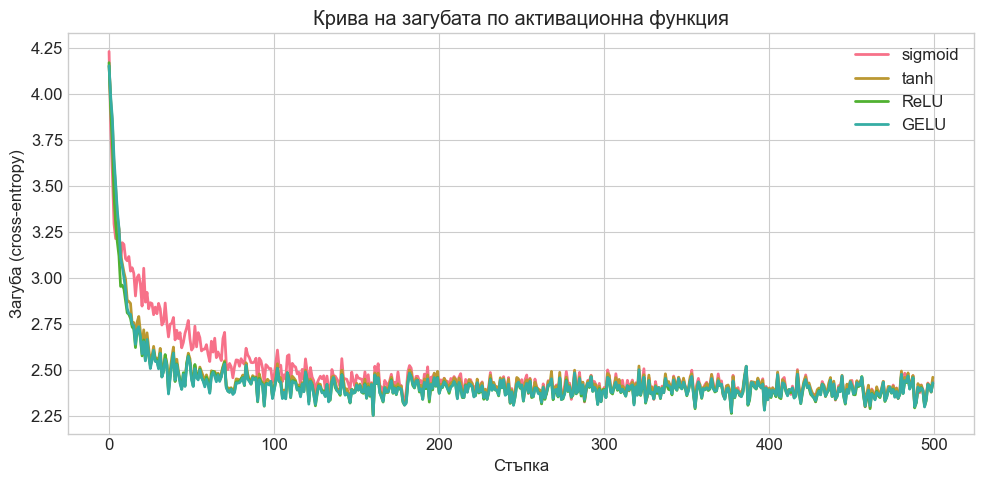

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
for name, losses in results.items():
    ax.plot(losses, label=name, linewidth=2)
ax.set_xlabel('Стъпка')
ax.set_ylabel('Загуба (cross-entropy)')
ax.set_title('Крива на загубата по активационна функция')
ax.legend()
plt.tight_layout()
plt.show()

GELU и ReLU се учат по-бързо от sigmoid/tanh. В съвременните трансформатори GELU (и варианти като SwiGLU) са стандарт.

Обобщение: sigmoid/tanh → исторически, ReLU → пробив, GELU/SwiGLU → съвременен стандарт в трансформатори.

---

## Блок 5: FFN, остатъчни връзки, нормализация на слоя [Обяснение + Демо]

**Цел:** Дълбоко гмуркане в компонентите от Блок 1.

### Мрежа с пряко предаване (FFN)

Структура: Linear → GELU → Linear

$$\text{FFN}(x) = W_2 \cdot \text{GELU}(W_1 x + b_1) + b_2$$

Размерности: $d_{model} \to 4 \cdot d_{model} \to d_{model}$ (разширяване и свиване).

Защо $4\times$? Емпирично — по-голямо разширение дава по-добри резултати. Повечето параметри на модела са тук!

In [17]:
# GPT-2: d_model=768 → 4*768=3072 → 768
d = 768
ffn_params = d * 4*d + 4*d + 4*d * d + d  # W1, b1, W2, b2
attn_params = d * 3*d + 3*d + d * d + d    # c_attn (Q,K,V) + c_proj

print(f"Параметри FFN на блок:    {ffn_params:>10,}")
print(f"Параметри Attention на блок: {attn_params:>10,}")
print(f"Отношение FFN/Attention:  {ffn_params/attn_params:.2f}x")
print(f"\nОбщо за 12 блока:")
print(f"  FFN:       {12*ffn_params:>12,}")
print(f"  Attention: {12*attn_params:>12,}")

Параметри FFN на блок:     4,722,432
Параметри Attention на блок:  2,362,368
Отношение FFN/Attention:  2.00x

Общо за 12 блока:
  FFN:         56,669,184
  Attention:   28,348,416


### Остатъчни връзки (Residual Connections)

$$\text{output} = x + \text{sublayer}(x)$$

"Добави промяна, вместо да заместиш" — градиентите могат да "прескочат" подслоя по идентитетния път.

Спомнете си от Блок 1 на Лекция 4: градиентите изчезват през 15+ слоя. Остатъчните връзки ги спасяват.

In [21]:
# Демо: поток на градиенти с и без остатъчни връзки
depth = 12
dim = 64

def measure_gradients(use_residual):
    torch.manual_seed(0)
    layers = [nn.Linear(dim, dim) for _ in range(depth)]
    x = torch.randn(1, dim, requires_grad=True)
    h = x
    for layer in layers:
        if use_residual:
            h = h + F.gelu(layer(h))
        else:
            h = F.gelu(layer(h))
    loss = h.sum()
    loss.backward()
    return x.grad.norm().item()

grad_no_res = measure_gradients(use_residual=False)
grad_with_res = measure_gradients(use_residual=True)

print(f"Без остатъчни връзки: ||grad|| = {grad_no_res:.6f}")
print(f"С остатъчни връзки:   ||grad|| = {grad_with_res:.6f}")
print(f"Разлика:              {grad_with_res / max(grad_no_res, 1e-10):.1f}x")

Без остатъчни връзки: ||grad|| = 0.000006
С остатъчни връзки:   ||grad|| = 78.442101
Разлика:              13637875.1x


### Нормализация на слоя (Layer Normalization)

Нормализира активациите по последното измерение: средно → 0, стандартно отклонение → 1.

$$\text{LayerNorm}(x) = \gamma \cdot \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta$$

- **Pre-norm** (GPT-2, модерни модели): LayerNorm *преди* подслоя
- **Post-norm** (оригиналният трансформатор): LayerNorm *след* подслоя

In [22]:
# LayerNorm на ръка vs nn.LayerNorm
x_demo = torch.tensor([[3.0, -1.0, 2.0, 5.0]])

# На ръка
mu = x_demo.mean(dim=-1, keepdim=True)
sigma = x_demo.std(dim=-1, keepdim=True, unbiased=False)
x_norm_manual = (x_demo - mu) / (sigma + 1e-5)

# С nn.LayerNorm
ln = nn.LayerNorm(4, elementwise_affine=False)
x_norm_torch = ln(x_demo)

print(f"Вход:              {x_demo.squeeze().tolist()}")
print(f"Средно:            {mu.item():.2f}")
print(f"Стд. отклонение:   {sigma.item():.2f}")
print(f"На ръка:           {x_norm_manual.squeeze().tolist()}")
print(f"nn.LayerNorm:      {x_norm_torch.detach().squeeze().tolist()}")
print(f"\nСлед нормализация: средно ≈ {x_norm_torch.mean().item():.4f}, std ≈ {x_norm_torch.std(unbiased=False).item():.4f}")

Вход:              [3.0, -1.0, 2.0, 5.0]
Средно:            2.25
Стд. отклонение:   2.17
На ръка:           [0.34640854597091675, -1.5011036396026611, -0.11546951532363892, 1.2701646089553833]
nn.LayerNorm:      [0.34640979766845703, -1.5011091232299805, -0.11546993255615234, 1.2701692581176758]

След нормализация: средно ≈ 0.0000, std ≈ 1.0000


**RMSNorm** — опростен вариант без центриране (без изваждане на средното). Използва се в LLaMA.

$$\text{RMSNorm}(x) = \frac{x}{\sqrt{\frac{1}{d}\sum x_i^2 + \epsilon}} \cdot \gamma$$

---

## Блок 6: nanoGPT: код и обучение [Демо]

**Цел:** Да разгледаме кода на nanoGPT, да заредим обучения модел и да генерираме текст.

### Преглед на кода в nanoGPT

Нека разгледаме как класовете в `pretrain_decoder.py` съответстват на компонентите от Блокове 1 и 3–5.

In [23]:
# Зареждаме класовете от pretrain_decoder.py
import sys
sys.path.insert(0, '.')
from pretrain_decoder import CausalSelfAttention, MLP, Block, GPT

print("Класове заредени от pretrain_decoder.py")

Класове заредени от pretrain_decoder.py


**`Block`** — един трансформаторен блок:

```python
class Block(nn.Module):
    def __init__(self, config):
        self.ln_1 = nn.LayerNorm(config["n_embd"])   # Нормализация на слоя
        self.attn = CausalSelfAttention(config)       # Причинно самовнимание
        self.ln_2 = nn.LayerNorm(config["n_embd"])   # Нормализация на слоя
        self.mlp = MLP(config)                        # FFN: Linear → GELU → Linear

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))              # LN → Attention → + остатъчна
        x = x + self.mlp(self.ln_2(x))               # LN → FFN → + остатъчна
        return x
```

**`MLP`** — мрежа с пряко предаване:
```python
class MLP(nn.Module):
    def __init__(self, config):
        self.c_fc = nn.Linear(config["n_embd"], 4 * config["n_embd"])   # Разширение 4x
        self.gelu = nn.GELU()                                            # Активация
        self.c_proj = nn.Linear(4 * config["n_embd"], config["n_embd"]) # Свиване
```

**`GPT`** — пълен модел:
```python
tok_emb + pos_emb → N × Block → LayerNorm → lm_head (логити)
```

Забележете **weight tying**: `tok_emb.weight = lm_head.weight` — вграждането и изходната глава споделят тегла.

### Зареждане на предварително обучения модел

Скриптът `pretrain_decoder.py` е обучил модел върху текста на Иван Вазов. Зареждаме контролната точка.

In [36]:
ls checkpoints/checkpoint_epoch_2.pt

checkpoints/checkpoint_epoch_2.pt


In [75]:
from tokenizers import Tokenizer

ckpt_dir = "checkpoints"
cpt = "checkpoints/checkpoint_epoch_8.pt"
base = f"{ckpt_dir}/decoder_vazov.pt"
ckpt = torch.load(cpt, map_location=device, weights_only=False)
config = ckpt["config"]

print("Конфигурация на модела:")
for k, v in config.items():
    print(f"  {k}: {v}")

Конфигурация на модела:
  vocab_size: 4096
  block_size: 256
  n_layer: 6
  n_head: 6
  n_embd: 384


In [76]:
model = GPT(config).to(device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

tokenizer = Tokenizer.from_file(f"{ckpt_dir}/tokenizer.json")

n_params = sum(p.numel() for p in model.parameters())
print(f"Параметри: {n_params:,}")
print(f"Речник: {config['vocab_size']} токена")
#print(f"\nФинална загуба: train={ckpt['final_train_loss']:.4f}, val={ckpt['final_val_loss']:.4f}")

Параметри: 12,318,720
Речник: 4096 токена


### Крива на загубата

In [77]:
def generate_text(prompt, max_tokens=200, temperature=0.8, top_k=50):
    encoded = tokenizer.encode(prompt)
    idx = torch.tensor([encoded.ids], dtype=torch.long, device=device)
    with torch.no_grad():
        generated = model.generate(idx, max_new_tokens=max_tokens,
                                   temperature=temperature, top_k=top_k)
    return tokenizer.decode(generated[0].tolist())

prompt = "Само Левски"
print(f"Подкана: '{prompt}'")
print(f"Генериран текст:\n")
print(generate_text(prompt))

Подкана: 'Само Левски'
Генериран текст:

Само Левски, да се за един човек, че ще се усмихна.
	— Не е.
	— Усурма.
	— Няма ли ти? — отговори докторът —
	— Аз е ли си?
	Едало, ноември.
	— Това е?
	— Ще се е на годия щеш? — каза докторът.
	— Аз на една си яден да си е работата… Тя не ме?
	— Амаш ли ти ще му помиперва при него, което и с тебе.
	Когато ми и с него? Зина отпусна, като ям.
	— Какво си ще те е, че е много ще се, паш, то, те ще да си да я помата на един у дома си досия, като пладя?
	— Вързо — Идим — каза Огнянов, за да ме.
	Кардашев


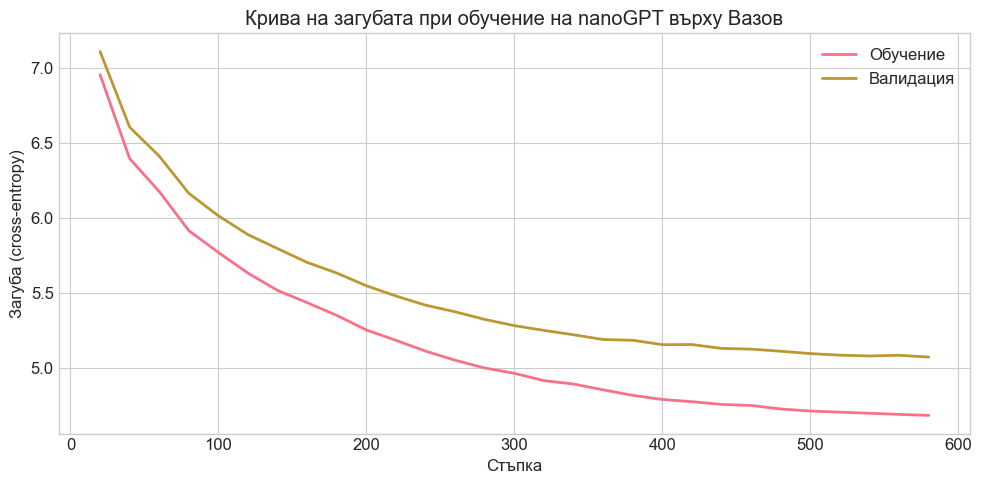

In [65]:
with open(f"{ckpt_dir}/decoder_loss.json") as f:
    loss_hist = json.load(f)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(loss_hist["step"], loss_hist["train"], label="Обучение", linewidth=2)
ax.plot(loss_hist["step"], loss_hist["val"], label="Валидация", linewidth=2)
ax.set_xlabel("Стъпка")
ax.set_ylabel("Загуба (cross-entropy)")
ax.set_title("Крива на загубата при обучение на nanoGPT върху Вазов")
ax.legend()
plt.tight_layout()
plt.show()

### Генериране на текст

Подаваме начало на изречение и оставяме модела да продължи.

In [55]:
# Генерираме няколко пъти — виждаме вариация
prompt2 = "България"
print(f"Подкана: '{prompt2}'\n")
for i in range(3):
    text = generate_text(prompt2, max_tokens=100, temperature=1.0)
    print(f"--- Генерация {i+1} ---")
    print(text)
    print()

Подкана: 'България'

--- Генерация 1 ---
България в него почувствува. Но той се обърна към Болянал.
	— И, това, защо и имах аз няма да се, нито за нас.
	Но защо пак минал в едно лице.
	— Ивайте, но ще види ни оставил.
	— Ах, че не знам да съм… Наумя.
	— Е, ти не е право да с едно — продължи пътя:
	— Той стана не съм, а

--- Генерация 2 ---
България си. Само не съм привлечеше. Той й излееше и с две с избираше отстъпна на тоя нощ, който са в една превестните му пътниците, които язнаваят поглед с булото минал с не беше негодели и за това, беше препа в България в тях, за да разсърдица. Тоя път и от мене, постима и не можеше да се забъртен от други, че съмнение

--- Генерация 3 ---
България, че на Далимина,
	светува, а по-добро,
	на да ямъл,
	в,
	врадят по-ший — за вас теди —

	чех,
	урото си,
	нескащ и при нас:
	и вража в Боск.

	Из тях на нас ти —
	Вързах!


	



За сравнение — от Лекция 1 (N-грам) и Лекция 2 (невронен биграм) видяхме доста по-лош текст от същия корпус. Трансформаторът генерира граматически по-свързан текст, макар и да "халюцинира" съдържание.

---

## Блок 7: nanoGPT: изследване + Обобщение [Демо + Дискусия]

**Цел:** Да изследваме какво е научил моделът — позиционни вграждания и модели на вниманието — и да обобщим лекцията.

### Изследване на модела

Разглеждаме позиционните вграждания — научил ли е нещо подобно на синусоидален модел?

Позиционни вграждания: torch.Size([256, 384])


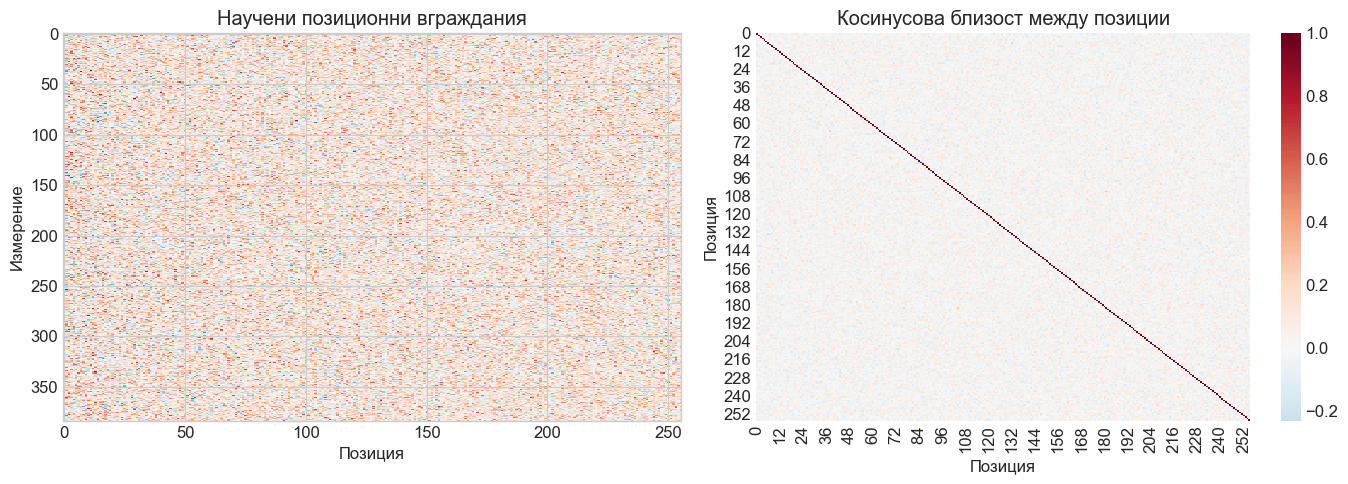

In [56]:
learned_pos = model.pos_emb.weight.detach().cpu()
print(f"Позиционни вграждания: {learned_pos.shape}")

# Косинусова близост
cos_sim_nano = F.cosine_similarity(
    learned_pos.unsqueeze(0), learned_pos.unsqueeze(1), dim=-1
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(learned_pos.numpy().T, aspect='auto', cmap='RdBu', interpolation='nearest')
axes[0].set_xlabel('Позиция')
axes[0].set_ylabel('Измерение')
axes[0].set_title('Научени позиционни вграждания')

sns.heatmap(cos_sim_nano.numpy(), cmap='RdBu_r', center=0, ax=axes[1])
axes[1].set_xlabel('Позиция')
axes[1].set_ylabel('Позиция')
axes[1].set_title('Косинусова близост между позиции')

plt.tight_layout()
plt.show()

### Визуализация на вниманието

Нека заглянем *вътре* в модела — какви модели (patterns) на вниманието е научил? Извличаме теглата на вниманието от всеки слой и ги визуализираме.

In [30]:
def get_attention_maps(model, input_ids):
    """Extract attention weights from all layers via forward hooks."""
    attention_maps = []

    def make_hook():
        def hook(module, inp, out):
            x = inp[0]
            B, T, C = x.size()
            qkv = module.c_attn(x)
            q, k, v = qkv.split(module.n_embd, dim=2)
            hs = C // module.n_head
            q = q.view(B, T, module.n_head, hs).transpose(1, 2)
            k = k.view(B, T, module.n_head, hs).transpose(1, 2)
            scale = 1.0 / math.sqrt(hs)
            attn_w = (q @ k.transpose(-2, -1)) * scale
            causal_mask = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
            attn_w = attn_w.masked_fill(causal_mask, float('-inf'))
            attn_w = F.softmax(attn_w, dim=-1)
            attention_maps.append(attn_w.detach().cpu())
        return hook

    hooks = [block.attn.register_forward_hook(make_hook()) for block in model.blocks]
    with torch.no_grad():
        model(input_ids)
    for h in hooks:
        h.remove()
    return attention_maps

# Tokenize a sample sentence
sample = "България е красива страна"
enc = tokenizer.encode(sample)
tokens = enc.tokens
input_ids = torch.tensor([enc.ids], dtype=torch.long, device=device)
print(f"Токени: {tokens}")

attn_maps = get_attention_maps(model, input_ids)
print(f"Извлечени {len(attn_maps)} слоя × {attn_maps[0].shape[1]} глави")

Токени: ['ÐĳÑĬÐ»Ð³Ð°', 'ÑĢÐ¸Ñı', 'ĠÐµ', 'ĠÐºÑĢÐ°ÑģÐ¸', 'Ð²Ð°', 'ĠÑģÑĤÑĢÐ°Ð½Ð°']
Извлечени 6 слоя × 6 глави


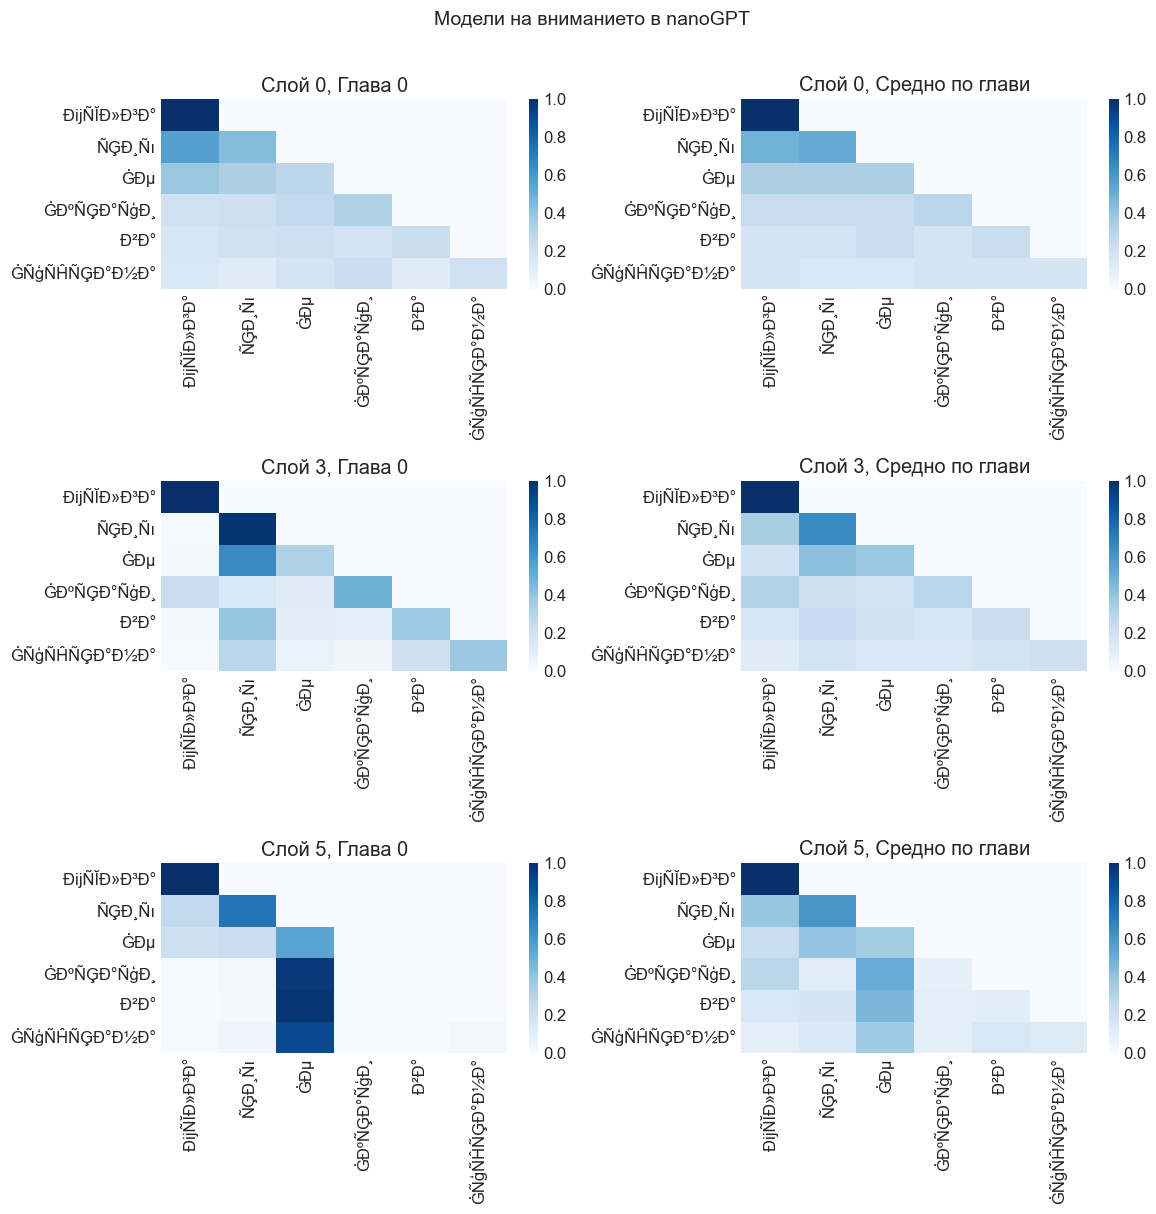

In [31]:
# Plot attention patterns for selected layers and heads
n_layers = len(attn_maps)
layers_to_show = [0, n_layers // 2, n_layers - 1]
n_show = len(layers_to_show)

fig, axes = plt.subplots(n_show, 2, figsize=(12, 4 * n_show))
if n_show == 1:
    axes = axes.reshape(1, -1)

for row, layer_idx in enumerate(layers_to_show):
    attn = attn_maps[layer_idx][0]  # (n_heads, T, T)
    # Head 0
    sns.heatmap(attn[0].numpy(), ax=axes[row, 0], cmap='Blues',
                xticklabels=tokens, yticklabels=tokens, vmin=0, vmax=1)
    axes[row, 0].set_title(f'Слой {layer_idx}, Глава 0')
    # Average across heads
    avg_attn = attn.mean(dim=0)
    sns.heatmap(avg_attn.numpy(), ax=axes[row, 1], cmap='Blues',
                xticklabels=tokens, yticklabels=tokens, vmin=0, vmax=1)
    axes[row, 1].set_title(f'Слой {layer_idx}, Средно по глави')

plt.suptitle('Модели на вниманието в nanoGPT', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Ранните слоеве обикновено се фокусират върху съседни токени (локални модели), а по-късните — върху по-глобални зависимости. Причинната маска е ясно видима: всеки ред показва внимание само към предишни позиции.

### Въпроси за дискусия

1. Нашият декодер вижда само предишните токени. Какво ще се случи, ако махнем причинната маска?
2. Защо моделите само-декодер замениха енкодер-декодер дори за превод?
3. Моделът генерира граматически свързан текст от малък корпус — но "халюцинира" съдържание. Защо?
4. Къде в архитектурата се "запаметява" фактическо знание — в FFN или в Attention?

---

## Обобщение

### Какво научихме днес

**Пълен трансформаторен блок (Блок 1):**
$$x \to \text{LN} \to \text{MHA} \to +x \to \text{LN} \to \text{FFN}(\text{GELU}) \to +x$$

**Три архитектури:**
- Само енкодер (BERT) — двупосочно, маскирано езиково моделиране
- Само декодер (GPT) — причинно, предвиждане на следващ токен — доминиращ днес
- Енкодер-декодер (T5) — двупосочно + причинно + кръстосано внимание

**Позиционно кодиране:** синусоидално (фиксирано) → обучаеми вграждания (GPT-2)

**Активационни функции:** sigmoid/tanh → ReLU → GELU/SwiGLU (съвременен стандарт)

**Компоненти:** FFN (4× разширение, повечето параметри), остатъчни връзки (градиентен поток), нормализация на слоя (стабилност)

**nanoGPT на практика:** всички компоненти — от позиционни вграждания до FFN — разпознати в реален код. Модел обучен на Вазов генерира свързан (макар и халюциниран) текст.

### Следваща лекция

**Лекция 6: Базови модели и данни за предварително обучение** — Откъде идват данните за обучение? Маскирано езиково моделиране vs предвиждане на следващ токен. Закони за мащабиране.

---

## Ресурси

- Vaswani et al. (2017) — [Attention Is All You Need](https://arxiv.org/abs/1706.03762)
- Devlin et al. (2018) — [BERT: Pre-training of Deep Bidirectional Transformers](https://arxiv.org/abs/1810.04805)
- Raffel et al. (2019) — [Exploring the Limits of Transfer Learning with T5](https://arxiv.org/abs/1910.10683)
- Hendrycks & Gimpel (2016) — [Gaussian Error Linear Units (GELUs)](https://arxiv.org/abs/1606.08415)
- He et al. (2015) — [Deep Residual Learning for Image Recognition](https://arxiv.org/abs/1512.03385)
- Jay Alammar — [The Illustrated Transformer](https://jalammar.github.io/illustrated-transformer/)
- Karpathy — [nanoGPT](https://github.com/karpathy/nanoGPT)